In [3]:
import os
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Current working directory:", os.getcwd())

PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "merged_players_dataset.csv"
METRICS_PATH = PROJECT_ROOT / "results" / "metrics.json"
PREDICTIONS_PATH = PROJECT_ROOT / "results" / "gb_test_predictions.csv"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)




Current working directory: c:\Users\justi\OneDrive\Documents\UMD\Senior\INST414\INST414-Project\INST414-Project\notebooks


In [4]:

from pathlib import Path
import json
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parents[0]
METRICS_PATH = PROJECT_ROOT / "results" / "metrics.json"


with open(METRICS_PATH, "r") as f:
    metrics = json.load(f)

rows = []

interpretability_map = {
    "baseline": "Very High",
    "linear_regression": "High",
    "ridge": "High",
    "random_forest": "Medium",
    "gradient_boosting": "Medium",
}

for model_name, splits in metrics.items():
    if "val" not in splits:
        continue
    val = splits["val"]
    rows.append({
        "Model": model_name,
        "R² (val)": round(val["r2"], 3),
        "RMSE (val)": round(val["rmse"], 0),
        "MAE (val)": round(val["mae"], 0),
        "Interpretability": interpretability_map.get(model_name, "Unknown"),
    })

val_comparison_df = pd.DataFrame(rows).sort_values("R² (val)", ascending=False)

print("\n Model Comparison (Validation Set):")
print(val_comparison_df.to_string(index=False))



 Model Comparison (Validation Set):
            Model  R² (val)  RMSE (val)  MAE (val) Interpretability
gradient_boosting     0.724   3003712.0   671679.0           Medium
    random_forest     0.483   4109116.0   835740.0           Medium
         baseline    -0.044   5839999.0  1385020.0        Very High
linear_regression   -70.994  48502099.0  3010809.0             High
            ridge   -71.013  48508395.0  3010644.0             High


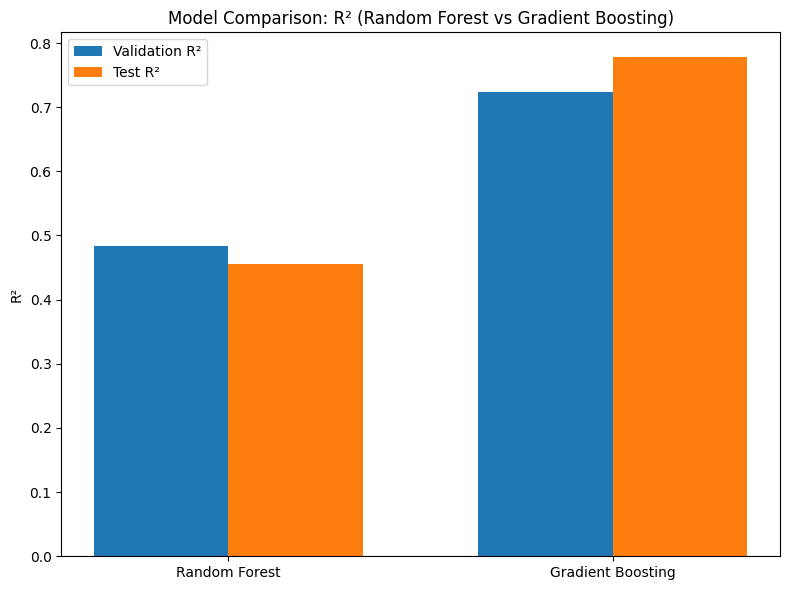

In [7]:

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parents[0]
METRICS_PATH = PROJECT_ROOT / "results" / "metrics.json"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


with open(METRICS_PATH, "r") as f:
    metrics = json.load(f)

models_to_plot = ["random_forest", "gradient_boosting"]

r2_val = []
r2_test = []

for m in models_to_plot:
    r2_val.append(metrics[m]["val"]["r2"])
    r2_test.append(metrics[m]["test"]["r2"])

x = np.arange(len(models_to_plot))
width = 0.35

plt.figure(figsize=(8, 6))
plt.bar(x - width/2, r2_val, width, label="Validation R²")
plt.bar(x + width/2, r2_test, width, label="Test R²")

plt.xticks(x, ["Random Forest", "Gradient Boosting"], rotation=0)
plt.ylabel("R²")
plt.title("Model Comparison: R² (Random Forest vs Gradient Boosting)")
plt.axhline(0, color="gray", linewidth=0.8)
plt.legend()
plt.tight_layout()

save_path = FIGURES_DIR / "rf_vs_gb_r2_comparison.png"
plt.savefig(save_path, dpi=300)


plt.show()


Project root: c:\Users\justi\OneDrive\Documents\UMD\Senior\INST414\INST414-Project\INST414-Project
Using data at: c:\Users\justi\OneDrive\Documents\UMD\Senior\INST414\INST414-Project\INST414-Project\data\processed\merged_players_dataset.csv
Rows after filtering: 15369
Features used: ['age', 'position', 'goals', 'assists', 'goal_contrib', 'minutes_played', 'nb_in_group', 'nb_on_pitch', 'clean_sheets', 'days_missed', 'height', 'club_mean_value', 'country_mean_value']
Top 25 most important features:


,feature,importance
10,club_mean_value,0.787323
0,age,0.065797
6,nb_on_pitch,0.050096
3,goal_contrib,0.023433
11,country_mean_value,0.020069
2,assists,0.018916
8,days_missed,0.011566
4,minutes_played,0.007071
5,nb_in_group,0.006387
9,height,0.004021


Saved feature importance table to: c:\Users\justi\OneDrive\Documents\UMD\Senior\INST414\INST414-Project\INST414-Project\reports\figures\gradient_boosting_feature_importance_top25.csv
Saved feature importance plot to: c:\Users\justi\OneDrive\Documents\UMD\Senior\INST414\INST414-Project\INST414-Project\reports\figures\gradient_boosting_feature_importance_top20.png


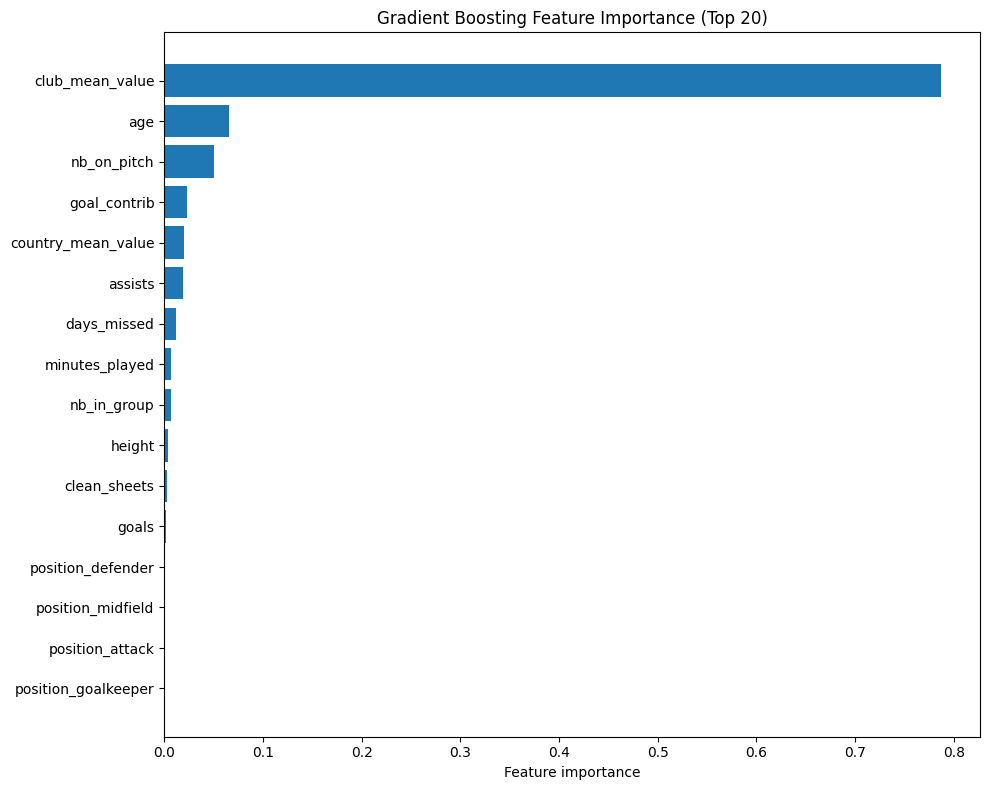

In [ ]:


from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline


PROJECT_ROOT = Path.cwd().parents[0]  
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "merged_players_dataset.csv"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Using data at:", DATA_PATH)


def load_and_prepare_data_for_notebook():
    
    df = pd.read_csv(DATA_PATH)

    
    df = df[df["market_value_eur"] > 0]

    
    for col in ["current_club_name", "position", "country_of_birth"]:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().str.lower()

    
    if "age" not in df.columns and "date_of_birth" in df.columns:
        df["date_of_birth"] = pd.to_datetime(df["date_of_birth"], errors="coerce")
        df["age"] = datetime.now().year - df["date_of_birth"].dt.year

 
    if "age" in df.columns:
        df = df[df["age"].between(16, 42)]

    
    if "goals" in df.columns and "assists" in df.columns:
        df["goal_contrib"] = df["goals"] + df["assists"]

    
    if "current_club_name" in df.columns:
        club_means = (
            df.groupby("current_club_name")["market_value_eur"]
            .mean()
            .rename("club_mean_value")
        )
        df = df.merge(
            club_means,
            how="left",
            left_on="current_club_name",
            right_index=True,
        )
    else:
        df["club_mean_value"] = np.nan

   
    if "country_of_birth" in df.columns:
        country_means = (
            df.groupby("country_of_birth")["market_value_eur"]
            .mean()
            .rename("country_mean_value")
        )
        df = df.merge(
            country_means,
            how="left",
            left_on="country_of_birth",
            right_index=True,
        )
    else:
        df["country_mean_value"] = np.nan

    
    global_mean = df["market_value_eur"].mean()
    df["club_mean_value"] = df["club_mean_value"].fillna(global_mean)
    df["country_mean_value"] = df["country_mean_value"].fillna(global_mean)

    candidate_features = [
        "age",
        "position",
        "goals",
        "assists",
        "goal_contrib",
        "minutes_played",
        "nb_in_group",
        "nb_on_pitch",
        "clean_sheets",
        "days_missed",
        "height",
        "club_mean_value",
        "country_mean_value",
    ]

    feature_cols = [c for c in candidate_features if c in df.columns]
    target_col = "market_value_eur"

    df = df.dropna(subset=[target_col] + feature_cols)

    X = df[feature_cols].copy()
    y = df[target_col].astype(float)
    y_log = np.log1p(y)

    print("Rows after filtering:", X.shape[0])
    print("Features used:", feature_cols)

    return X, y_log, feature_cols


def build_preprocessor_for_notebook(feature_cols):
    """
    Same idea as build_preprocessor in train.py:
    - numeric features: StandardScaler
    - position: OneHotEncoder
    """
    categorical_features = [c for c in feature_cols if c == "position"]
    numeric_features = [c for c in feature_cols if c not in categorical_features]

    numeric_transformer = StandardScaler()
    categorical_transformer = OneHotEncoder(handle_unknown="ignore")

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ]
    )

    return preprocessor, numeric_features, categorical_features



X, y_log, feature_cols = load_and_prepare_data_for_notebook()
preprocessor, numeric_features, categorical_features = build_preprocessor_for_notebook(feature_cols)


gb_reg = GradientBoostingRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
)

gb_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", gb_reg),
    ]
)


gb_model.fit(X, y_log)


preprocessor = gb_model.named_steps["preprocess"]
gb_reg = gb_model.named_steps["model"]

feature_names = []

for name, transformer, cols in preprocessor.transformers_:
    if name == "num":
        feature_names.extend(cols)
    elif name == "cat":
        ohe = transformer
        try:
            ohe_names = ohe.get_feature_names(cols)
        except Exception:
            ohe_names = ohe.get_feature_names_out(cols)
        feature_names.extend(list(ohe_names))

importances = gb_reg.feature_importances_

feat_imp = pd.DataFrame(
    {"feature": feature_names, "importance": importances}
).sort_values("importance", ascending=False)

print("Top 25 most important features:")
display(feat_imp.head(25))


fi_csv_path = FIGURES_DIR / "gradient_boosting_feature_importance_top25.csv"
feat_imp.head(25).to_csv(fi_csv_path, index=False)



top_n = 20
top_feats = feat_imp.head(top_n).iloc[::-1]

plt.figure(figsize=(10, 8))
plt.barh(top_feats["feature"], top_feats["importance"])
plt.xlabel("Feature importance")
plt.title(f"Gradient Boosting Feature Importance (Top {top_n})")
plt.tight_layout()

fi_png_path = FIGURES_DIR / "gradient_boosting_feature_importance_top20.png"
plt.savefig(fi_png_path, dpi=300)


plt.show()


Project root: C:\Users\justi\OneDrive\Documents\UMD\Senior\INST414\INST414-Project\INST414-Project
Using data at: C:\Users\justi\OneDrive\Documents\UMD\Senior\INST414\INST414-Project\INST414-Project\data\processed\merged_players_dataset.csv
Rows after filtering: 15369
Features used: ['age', 'position', 'goals', 'assists', 'goal_contrib', 'minutes_played', 'nb_in_group', 'nb_on_pitch', 'clean_sheets', 'days_missed', 'height', 'club_mean_value', 'country_mean_value']
Fitting Gradient Boosting model on full dataset (for scatter plot)...
Saved actual vs predicted plot to: C:\Users\justi\OneDrive\Documents\UMD\Senior\INST414\INST414-Project\INST414-Project\reports\figures\gradient_boosting_actual_vs_predicted.png


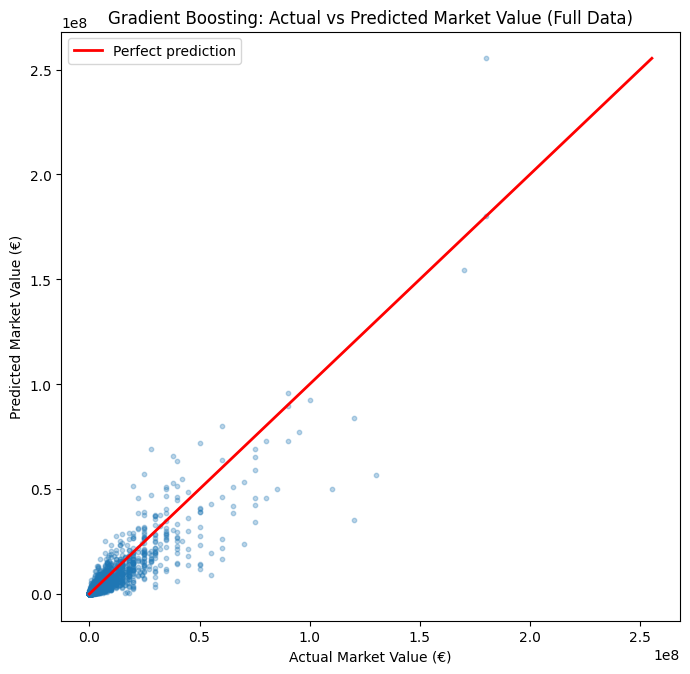

In [ ]:


from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline

PROJECT_ROOT = Path.cwd().resolve().parents[0]   
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "merged_players_dataset.csv"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)



def load_and_prepare_data_for_scatter():
    
    df = pd.read_csv(DATA_PATH)

    
    df = df[df["market_value_eur"] > 0].copy()

   
    for col in ["current_club_name", "position", "country_of_birth"]:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().str.lower()

    
    if "age" not in df.columns and "date_of_birth" in df.columns:
        df["date_of_birth"] = pd.to_datetime(df["date_of_birth"], errors="coerce")
        df["age"] = datetime.now().year - df["date_of_birth"].dt.year

  
    if "age" in df.columns:
        df = df[df["age"].between(16, 42)]

   
    if "goals" in df.columns and "assists" in df.columns:
        df["goal_contrib"] = df["goals"] + df["assists"]

   
    if "current_club_name" in df.columns:
        club_means = (
            df.groupby("current_club_name")["market_value_eur"]
            .mean()
            .rename("club_mean_value")
        )
        df = df.merge(
            club_means,
            how="left",
            left_on="current_club_name",
            right_index=True,
        )
    else:
        df["club_mean_value"] = np.nan

   
    if "country_of_birth" in df.columns:
        country_means = (
            df.groupby("country_of_birth")["market_value_eur"]
            .mean()
            .rename("country_mean_value")
        )
        df = df.merge(
            country_means,
            how="left",
            left_on="country_of_birth",
            right_index=True,
        )
    else:
        df["country_mean_value"] = np.nan

   
    global_mean = df["market_value_eur"].mean()
    df["club_mean_value"] = df["club_mean_value"].fillna(global_mean)
    df["country_mean_value"] = df["country_mean_value"].fillna(global_mean)

    candidate_features = [
        "age",
        "position",
        "goals",
        "assists",
        "goal_contrib",
        "minutes_played",
        "nb_in_group",
        "nb_on_pitch",
        "clean_sheets",
        "days_missed",
        "height",
        "club_mean_value",
        "country_mean_value",
    ]

    feature_cols = [c for c in candidate_features if c in df.columns]
    target_col = "market_value_eur"

    df = df.dropna(subset=[target_col] + feature_cols)

    X = df[feature_cols].copy()
    y = df[target_col].astype(float)
    y_log = np.log1p(y)

    print("Rows after filtering:", X.shape[0])
    print("Features used:", feature_cols)

    return X, y_log, feature_cols


def build_preprocessor_for_scatter(feature_cols):
    """
    Same preprocessing as train.py:
    - numeric features: StandardScaler
    - position: OneHotEncoder
    """
    categorical_features = [c for c in feature_cols if c == "position"]
    numeric_features = [c for c in feature_cols if c not in categorical_features]

    numeric_transformer = StandardScaler()
    categorical_transformer = OneHotEncoder(handle_unknown="ignore")

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ]
    )

    return preprocessor



X, y_log, feature_cols = load_and_prepare_data_for_scatter()
y_true = np.expm1(y_log)  

preprocessor = build_preprocessor_for_scatter(feature_cols)

gb_reg = GradientBoostingRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
)

gb_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", gb_reg),
    ]
)

print("Fitting Gradient Boosting model on full dataset (for scatter plot)...")
gb_model.fit(X, y_log)


y_pred_log = gb_model.predict(X)
y_pred = np.expm1(y_pred_log)


plt.figure(figsize=(7, 7))
plt.scatter(y_true, y_pred, alpha=0.3, s=10)
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linewidth=2,
    label="Perfect prediction",
)
plt.xlabel("Actual Market Value (€)")
plt.ylabel("Predicted Market Value (€)")
plt.title("Gradient Boosting: Actual vs Predicted Market Value (Full Data)")
plt.legend()
plt.tight_layout()

scatter_path = FIGURES_DIR / "gradient_boosting_actual_vs_predicted.png"
plt.savefig(scatter_path, dpi=300)
print(f"Saved actual vs predicted plot to: {scatter_path}")
plt.show()


Saving Q-Q plot to: c:\Users\justi\OneDrive\Documents\UMD\Senior\INST414\INST414-Project\reports\figures\qq_plot_gb.png


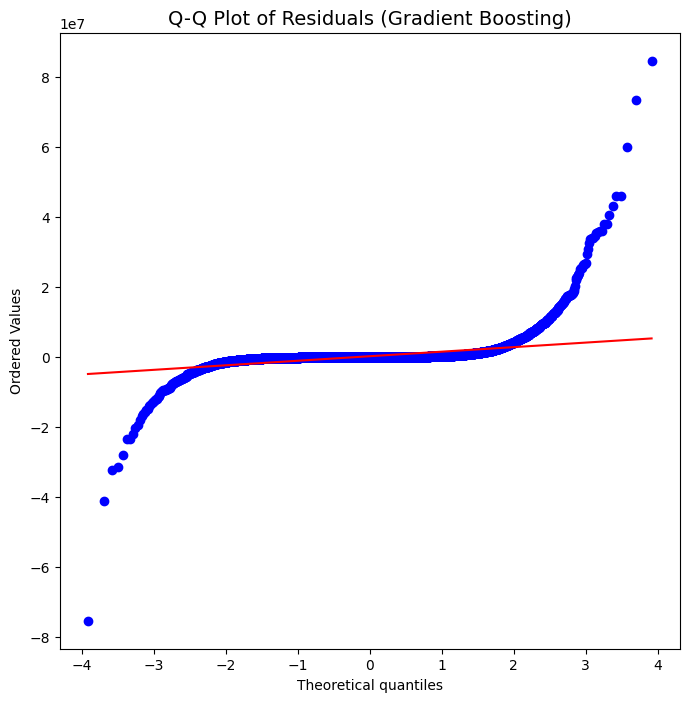

Saved Q-Q plot to:
c:\Users\justi\OneDrive\Documents\UMD\Senior\INST414\INST414-Project\reports\figures\qq_plot_gb.png


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from pathlib import Path


PROJECT_ROOT = Path.cwd().parents[1]   
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

qq_path = FIG_DIR / "qq_plot_gb.png"
print("Saving Q-Q plot to:", qq_path)


residuals = y_true - y_pred


plt.figure(figsize=(8, 8))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals (Gradient Boosting)", fontsize=14)

plt.savefig(qq_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved Q-Q plot to:\n{qq_path}")


Project root: C:\Users\justi\OneDrive\Documents\UMD\Senior\INST414\INST414-Project\INST414-Project
Using data: C:\Users\justi\OneDrive\Documents\UMD\Senior\INST414\INST414-Project\INST414-Project\data\processed\merged_players_dataset.csv
Rows after filtering: 15369
Feature columns: ['age', 'position', 'goals', 'assists', 'goal_contrib', 'minutes_played', 'nb_in_group', 'nb_on_pitch', 'clean_sheets', 'days_missed', 'height', 'club_mean_value', 'country_mean_value']
Saved residual plot to: C:\Users\justi\OneDrive\Documents\UMD\Senior\INST414\INST414-Project\INST414-Project\reports\figures\gb_residuals_vs_predicted.png


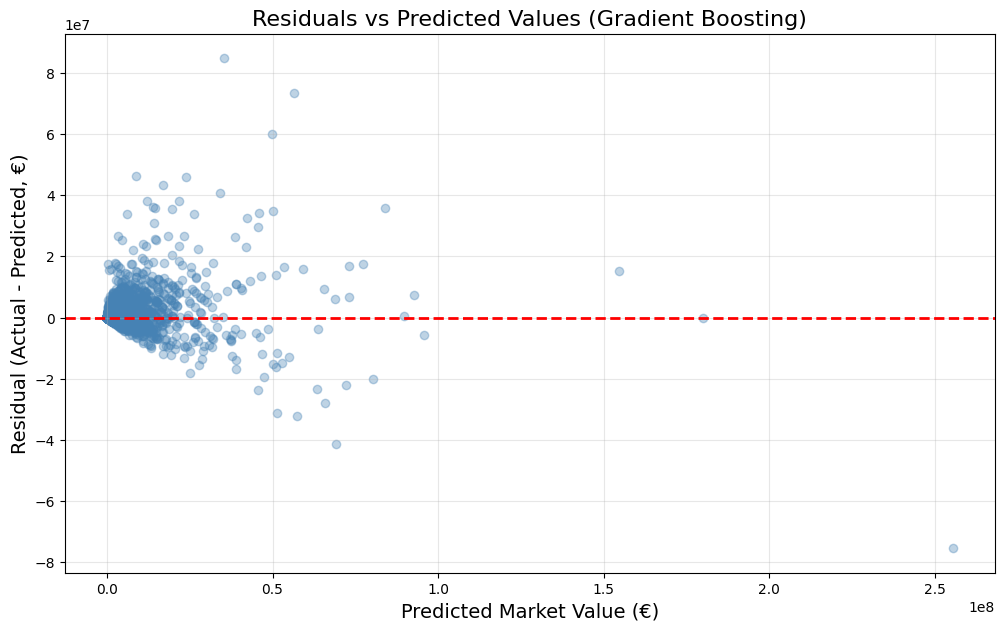

Mean residual: 246180.52242135
Median residual: 4152.878158136649
Residual std deviation: 2530965.42232783


In [19]:


from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline


PROJECT_ROOT = Path.cwd().resolve().parents[0]   
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "merged_players_dataset.csv"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Using data:", DATA_PATH)


def load_and_prepare_data_for_residuals():
    
    df = pd.read_csv(DATA_PATH)

    
    df = df[df["market_value_eur"] > 0].copy()

    
    for col in ["current_club_name", "position", "country_of_birth"]:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().str.lower()

    
    if "age" not in df.columns and "date_of_birth" in df.columns:
        df["date_of_birth"] = pd.to_datetime(df["date_of_birth"], errors="coerce")
        df["age"] = datetime.now().year - df["date_of_birth"].dt.year

   
    if "age" in df.columns:
        df = df[df["age"].between(16, 42)]

    
    if "goals" in df.columns and "assists" in df.columns:
        df["goal_contrib"] = df["goals"] + df["assists"]

    
    if "current_club_name" in df.columns:
        club_means = (
            df.groupby("current_club_name")["market_value_eur"]
            .mean()
            .rename("club_mean_value")
        )
        df = df.merge(
            club_means,
            how="left",
            left_on="current_club_name",
            right_index=True,
        )
    else:
        df["club_mean_value"] = np.nan

    
    if "country_of_birth" in df.columns:
        country_means = (
            df.groupby("country_of_birth")["market_value_eur"]
            .mean()
            .rename("country_mean_value")
        )
        df = df.merge(
            country_means,
            how="left",
            left_on="country_of_birth",
            right_index=True,
        )
    else:
        df["country_mean_value"] = np.nan

    
    global_mean = df["market_value_eur"].mean()
    df["club_mean_value"] = df["club_mean_value"].fillna(global_mean)
    df["country_mean_value"] = df["country_mean_value"].fillna(global_mean)

    candidate_features = [
        "age",
        "position",
        "goals",
        "assists",
        "goal_contrib",
        "minutes_played",
        "nb_in_group",
        "nb_on_pitch",
        "clean_sheets",
        "days_missed",
        "height",
        "club_mean_value",
        "country_mean_value",
    ]

    feature_cols = [c for c in candidate_features if c in df.columns]
    target_col = "market_value_eur"

    df = df.dropna(subset=[target_col] + feature_cols)

    X = df[feature_cols].copy()
    y = df[target_col].astype(float)
    y_log = np.log1p(y)

    print("Rows after filtering:", X.shape[0])
    print("Feature columns:", feature_cols)

    return X, y_log, feature_cols


def build_preprocessor_for_residuals(feature_cols):
    """Same preprocessing as train.py: StandardScaler for numeric, OneHotEncoder for position."""
    categorical_features = [c for c in feature_cols if c == "position"]
    numeric_features = [c for c in feature_cols if c not in categorical_features]

    numeric_transformer = StandardScaler()
    categorical_transformer = OneHotEncoder(handle_unknown="ignore")

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ]
    )

    return preprocessor

# ---- Load data & train model on full dataset ----
X, y_log, feature_cols = load_and_prepare_data_for_residuals()
y_true = np.expm1(y_log)  

preprocessor = build_preprocessor_for_residuals(feature_cols)

gb_reg = GradientBoostingRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
)

gb_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", gb_reg),
    ]
)


gb_model.fit(X, y_log)


y_pred_log = gb_model.predict(X)
y_pred = np.expm1(y_pred_log)
residuals = y_true - y_pred


plt.figure(figsize=(12, 7))
plt.scatter(y_pred, residuals, alpha=0.35, color="steelblue")
plt.axhline(0, color="red", linestyle="--", linewidth=2)

plt.title("Residuals vs Predicted Values (Gradient Boosting)", fontsize=16)
plt.xlabel("Predicted Market Value (€)", fontsize=14)
plt.ylabel("Residual (Actual - Predicted, €)", fontsize=14)
plt.grid(alpha=0.3)

out_path = FIG_DIR / "gb_residuals_vs_predicted.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
print(f"Saved residual plot to: {out_path}")

plt.show()

print("Mean residual:", float(np.mean(residuals)))
print("Median residual:", float(np.median(residuals)))
print("Residual std deviation:", float(np.std(residuals)))
